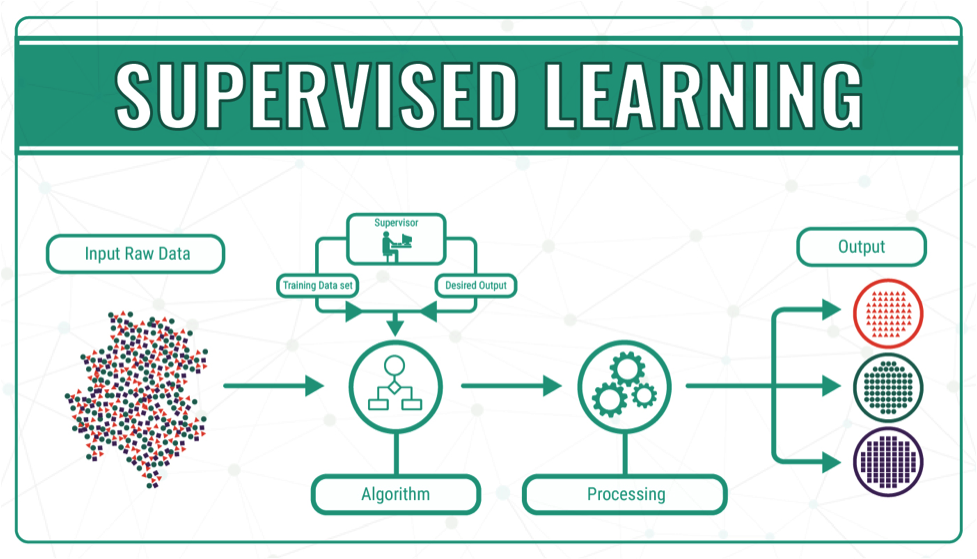


# **Classification**  
Other Supervised Classification problems

## **Breast cancer**  => proving different algorithms
Purpose: predict for different attributes describing an image if this case is a breast cancer or not

<img src="images/bcancer.jpg" width="400">

### Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

### Data

In [2]:
from sklearn.datasets import load_breast_cancer

data = load_breast_cancer()

X = data.data
y = data.target

In [3]:
print(data.DESCR)

.. _breast_cancer_dataset:

Breast cancer wisconsin (diagnostic) dataset
--------------------------------------------

**Data Set Characteristics:**

:Number of Instances: 569

:Number of Attributes: 30 numeric, predictive attributes and the class

:Attribute Information:
    - radius (mean of distances from center to points on the perimeter)
    - texture (standard deviation of gray-scale values)
    - perimeter
    - area
    - smoothness (local variation in radius lengths)
    - compactness (perimeter^2 / area - 1.0)
    - concavity (severity of concave portions of the contour)
    - concave points (number of concave portions of the contour)
    - symmetry
    - fractal dimension ("coastline approximation" - 1)

    The mean, standard error, and "worst" or largest (mean of the three
    worst/largest values) of these features were computed for each image,
    resulting in 30 features.  For instance, field 0 is Mean Radius, field
    10 is Radius SE, field 20 is Worst Radius.

    - 

In [4]:
dataframe= pd.DataFrame(data.data, columns=data.feature_names)
dataframe.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 30 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

### Transform data

In [5]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
X = scaler.fit_transform(X)


### Split data

In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state=5, shuffle=True)

### Random Forest

In [7]:
from sklearn.ensemble import RandomForestClassifier

classifier = RandomForestClassifier(n_estimators = 10, criterion = 'entropy', random_state = 0)
classifier.fit(X_train, y_train)

RandomForestClassifier(criterion='entropy', n_estimators=10, random_state=0)

In [8]:
y_pred = classifier.predict(X_test)

[[44  4]
 [ 1 65]]
Accuracy:2 0.956140350877193


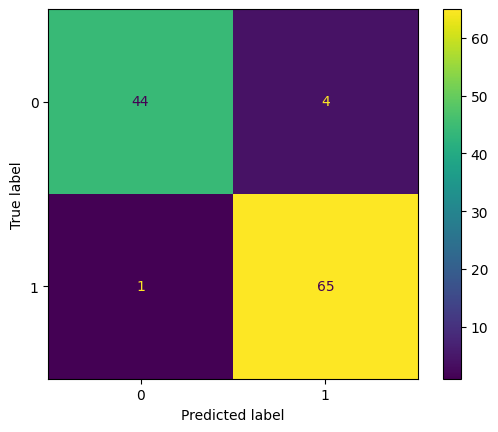

In [13]:
from sklearn.metrics import confusion_matrix, accuracy_score, ConfusionMatrixDisplay, classification_report

cm = confusion_matrix(y_test, y_pred)
print(cm)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
acc = accuracy_score(y_test, y_pred)
print("Accuracy:2", acc)

#### Accuracy, Recall, f1 score

[[44  4]
 [ 1 65]]
              precision    recall  f1-score   support

           0       0.98      0.92      0.95        48
           1       0.94      0.98      0.96        66

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



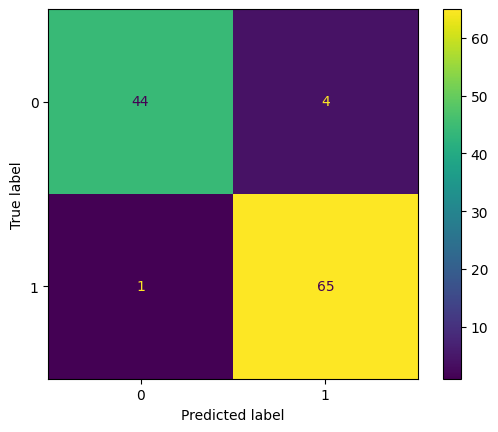

In [14]:
y_pred = classifier.predict(X_test)
y_pred_prob = classifier.predict_proba(X_test)[:, 1]  #probabilities for every prediction

cm = confusion_matrix(y_test, y_pred)
print(cm)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()


print(classification_report(y_test, y_pred))

#### ROC Curve

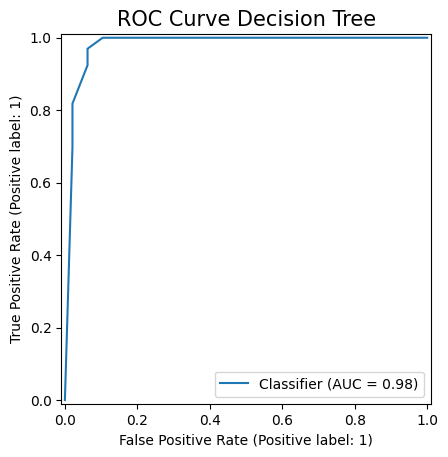

In [21]:

from sklearn.metrics import RocCurveDisplay
import matplotlib.pyplot as plt


RocCurveDisplay.from_predictions(y_test, y_pred_prob)
plt.title('ROC Curve Decision Tree', fontsize=15)
plt.show()

### Logistic regression

In [23]:
from sklearn.linear_model import LogisticRegression

classifier = LogisticRegression(random_state = 0)
classifier.fit(X_train, y_train)

LogisticRegression(random_state=0)

In [24]:
Y_pred = classifier.predict(X_test)

In [27]:
from sklearn.metrics import confusion_matrix, accuracy_score
cm = confusion_matrix(y_test, Y_pred)
print(cm)
acc = accuracy_score(y_test, Y_pred)
print("Accuracy:", acc)

[[45  3]
 [ 0 66]]
Accuracy: 0.9736842105263158


### K nearest neighbours

In [28]:
from sklearn.neighbors import KNeighborsClassifier

classifier = KNeighborsClassifier(n_neighbors = 5, metric = 'minkowski', p = 2)
classifier.fit(X_train, y_train)

KNeighborsClassifier()

In [29]:
Y_pred = classifier.predict(X_test)

In [31]:
from sklearn.metrics import confusion_matrix, accuracy_score
cm = confusion_matrix(y_test, Y_pred)
print(cm)
acc = accuracy_score(y_test, Y_pred)
print("Accuracy:", acc)

[[44  4]
 [ 0 66]]
Accuracy: 0.9649122807017544


### SVM

In [32]:
from sklearn.svm import SVC

classifier = SVC(kernel = 'linear', random_state = 0)
classifier.fit(X_train, y_train)

SVC(kernel='linear', random_state=0)

In [33]:
Y_pred = classifier.predict(X_test)

In [34]:
from sklearn.metrics import confusion_matrix, accuracy_score
cm = confusion_matrix(y_test, Y_pred)
print(cm)
acc = accuracy_score(y_test, Y_pred)
print("Accuracy:", acc)

[[46  2]
 [ 0 66]]
Accuracy: 0.9824561403508771


### Perceptron

In [35]:
from sklearn.neural_network import MLPClassifier

classifier = MLPClassifier(solver='adam',random_state=1)
classifier.fit(X_train, y_train)

/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


MLPClassifier(random_state=1)

In [36]:
Y_pred = classifier.predict(X_test)

In [37]:
from sklearn.metrics import confusion_matrix, accuracy_score
cm = confusion_matrix(y_test, Y_pred)
print(cm)
acc = accuracy_score(y_test, Y_pred)
print("Accuracy:", acc)

[[46  2]
 [ 0 66]]
Accuracy: 0.9824561403508771


## **Digits Dataset**  => Measuring the performance
Purpose: predict for an image with digit is related with

### Data
<img src="images/digits.jpg" width="400">

In [38]:
from sklearn.datasets import load_digits

digits = load_digits()
X = digits.data
y = digits.target

In [39]:
print('data: ',digits.data[0], '\n\n\nTarget: ',digits.target[0])

data:  [ 0.  0.  5. 13.  9.  1.  0.  0.  0.  0. 13. 15. 10. 15.  5.  0.  0.  3.
 15.  2.  0. 11.  8.  0.  0.  4. 12.  0.  0.  8.  8.  0.  0.  5.  8.  0.
  0.  9.  8.  0.  0.  4. 11.  0.  1. 12.  7.  0.  0.  2. 14.  5. 10. 12.
  0.  0.  0.  0.  6. 13. 10.  0.  0.  0.] 


Target:  0


In [40]:
digits.images[0]

array([[ 0.,  0.,  5., 13.,  9.,  1.,  0.,  0.],
       [ 0.,  0., 13., 15., 10., 15.,  5.,  0.],
       [ 0.,  3., 15.,  2.,  0., 11.,  8.,  0.],
       [ 0.,  4., 12.,  0.,  0.,  8.,  8.,  0.],
       [ 0.,  5.,  8.,  0.,  0.,  9.,  8.,  0.],
       [ 0.,  4., 11.,  0.,  1., 12.,  7.,  0.],
       [ 0.,  2., 14.,  5., 10., 12.,  0.,  0.],
       [ 0.,  0.,  6., 13., 10.,  0.,  0.,  0.]])

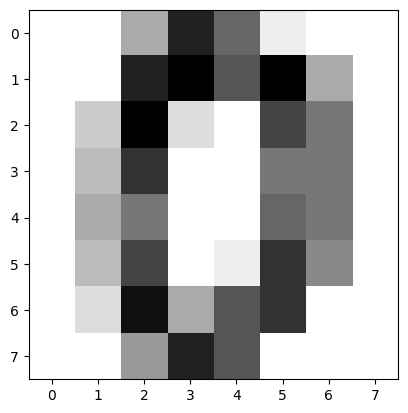

In [41]:
plt.imshow(digits.images[0], cmap=plt.cm.binary)

In [42]:
X = digits.data
y = digits.target

### Split data

In [43]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state=5, shuffle=True)

### Model: Random Forest

In [44]:
from sklearn.ensemble import RandomForestClassifier

classifier = RandomForestClassifier(n_estimators = 10, criterion = 'entropy', random_state = 0)
classifier.fit(X_train, y_train)

RandomForestClassifier(criterion='entropy', n_estimators=10, random_state=0)

In [45]:
y_pred = classifier.predict(X_test)

### Confusion matrix

In [46]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
cm

array([[35,  0,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 0, 35,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 0,  0, 35,  0,  0,  0,  0,  0,  0,  1],
       [ 0,  0,  1, 31,  1,  1,  0,  0,  2,  1],
       [ 0,  0,  0,  0, 32,  0,  0,  0,  0,  0],
       [ 0,  0,  0,  0,  0, 44,  0,  0,  0,  2],
       [ 0,  0,  0,  0,  1,  0, 29,  0,  0,  0],
       [ 0,  0,  0,  0,  1,  0,  0, 40,  0,  1],
       [ 0,  2,  0,  1,  0,  0,  0,  1, 34,  0],
       [ 0,  1,  0,  0,  0,  1,  0,  1,  0, 26]])

(10.5, -0.5)

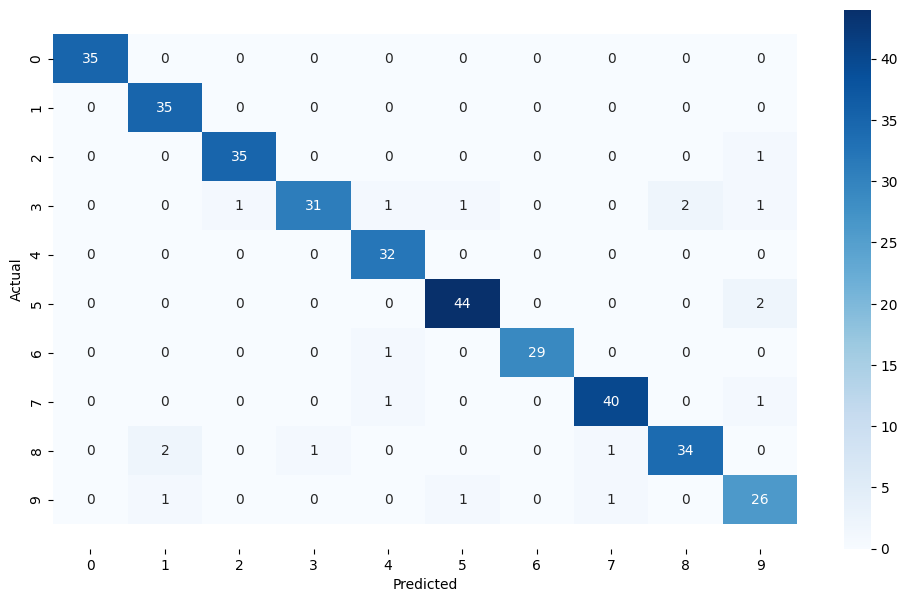

In [47]:
import seaborn as sns

fig, ax = plt.subplots(figsize=(12,7))

sns.heatmap(cm, cmap="Blues", annot=True)
plt.xlabel('Predicted')
plt.ylabel('Actual')

bottom, top = ax.get_ylim()
ax.set_ylim(bottom + 0.5, top - 0.5)

### Accuracy, Precision, Recall and F1-score

In [48]:
from sklearn.metrics import roc_auc_score, f1_score, confusion_matrix, roc_curve, auc, classification_report

print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        35
           1       0.92      1.00      0.96        35
           2       0.97      0.97      0.97        36
           3       0.97      0.84      0.90        37
           4       0.91      1.00      0.96        32
           5       0.96      0.96      0.96        46
           6       1.00      0.97      0.98        30
           7       0.95      0.95      0.95        42
           8       0.94      0.89      0.92        38
           9       0.84      0.90      0.87        29

    accuracy                           0.95       360
   macro avg       0.95      0.95      0.95       360
weighted avg       0.95      0.95      0.95       360



### Roc Curve
Only for binary classes